In [12]:
from pathlib import Path
import pandas as pd

AUDIO_ROOT = Path("/Users/alicia/Library/CloudStorage/GoogleDrive-adaniell@usc.edu/My Drive/CSCI567 Project/modma_data/audio_lanzhou_2015")
DROP_COLS = ("file", "start", "end")  # openSMILE metadata we don't want as features

func_dfs: dict[int, pd.DataFrame] = {}
subject_dirs = sorted(p for p in AUDIO_ROOT.iterdir() if p.is_dir())

for file_idx in range(1, 30):
    stem = f"{file_idx:02d}"
    rows = {}
    feature_cols = None

    for subj_dir in subject_dirs:
        func_csv = subj_dir / f"{stem}_openSMILE_func.csv"
        if not func_csv.exists():
            continue
        df = pd.read_csv(func_csv)
        df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

        if feature_cols is None:
            feature_cols = list(df.columns)
        elif list(df.columns) != feature_cols:
            raise ValueError(
                f"Column mismatch in {func_csv}:\n"
                f"  expected {feature_cols[:3]}...\n"
                f"  got      {list(df.columns)[:3]}..."
            )

        rows[subj_dir.name] = df.iloc[0]

    out = pd.DataFrame.from_dict(rows, orient="index", columns=feature_cols)
    out.index.name = "subject_id"
    func_dfs[file_idx] = out

# Sanity check — should print real feature names, not 0..87
print(func_dfs[1].columns.tolist()[:5])
print(func_dfs[1].shape)

['F0semitoneFrom27.5Hz_sma3nz_amean', 'F0semitoneFrom27.5Hz_sma3nz_stddevNorm', 'F0semitoneFrom27.5Hz_sma3nz_percentile20.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile50.0', 'F0semitoneFrom27.5Hz_sma3nz_percentile80.0']
(52, 88)


In [13]:
# CELL 3 — Load the subject-info and audio-file-map CSVs.
#
# subject_info:   one row per audio subject (52 rows).
#                 Columns: group, age, gender, edu_years, PHQ-9,
#                          CTQ-SF, LES, SSRS, GAD-7, PSQI.
#                 Indexed by subject_id (zero-padded 8-digit string).
# audio_file_map: one row per wav file number 1..29 (29 rows).
#                 Columns: task, task_number, valence, notes.

from pathlib import Path
import pandas as pd

CSV_ROOT = Path("/Users/alicia/Library/CloudStorage/GoogleDrive-adaniell@usc.edu/My Drive/CSCI567 Project")

subject_info = pd.read_csv(
    CSV_ROOT / "subject_info_map.csv",
    dtype={"subject_id": str},
).set_index("subject_id")

audio_file_map = pd.read_csv(CSV_ROOT / "audio_file_map.csv")

print(f"subject_info:    {subject_info.shape}  "
      f"groups={subject_info['group'].value_counts().to_dict()}")
print(f"audio_file_map:  {audio_file_map.shape}  "
      f"tasks={audio_file_map['task'].value_counts().to_dict()}")
print(f"PHQ-9 — MDD range {subject_info.loc[subject_info.group=='MDD', 'PHQ-9'].min()}"
      f"–{subject_info.loc[subject_info.group=='MDD', 'PHQ-9'].max()}, "
      f"HC range {subject_info.loc[subject_info.group=='HC', 'PHQ-9'].min()}"
      f"–{subject_info.loc[subject_info.group=='HC', 'PHQ-9'].max()}")
subject_info.head(3)


subject_info:    (52, 10)  groups={'HC': 29, 'MDD': 23}
audio_file_map:  (29, 5)  tasks={'Interview': 18, 'Word Reading': 6, 'Picture Description': 4, 'Passage Reading': 1}
PHQ-9 — MDD range 6–25, HC range 0–9


,group,age,gender,edu_years,PHQ-9,CTQ-SF,LES,SSRS,GAD-7,PSQI
subject_id,,,,,,,,,,
02010002,MDD,18,F,12,23,77,-143,31,18,12
02010004,MDD,25,F,19,12,53,-44,38,13,11
02010005,MDD,20,M,16,19,49,-3,28,11,5


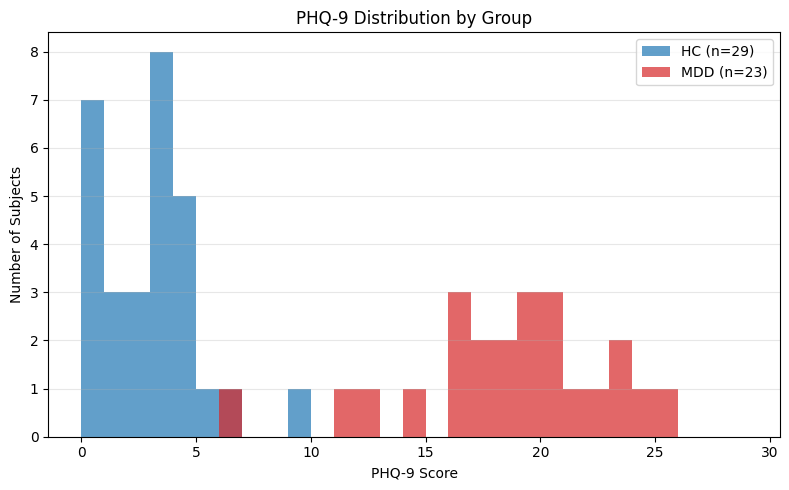

In [14]:
## PHQ-9 Distribution by Group
#
# Histogram showing the distribution of PHQ-9 depression severity scores for the MDD (Major Depressive Disorder) 
# and HC (Healthy Control) groups. PHQ-9 ranges from 0–27, with higher scores indicating more severe depression. 
# This helps us see whether the two groups are well-separated in terms of depression severity, which matters for 
# the prediction task.

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

mdd_scores = subject_info.loc[subject_info["group"] == "MDD", "PHQ-9"]
hc_scores = subject_info.loc[subject_info["group"] == "HC", "PHQ-9"]

ax.hist(hc_scores, bins=range(0, 30), alpha=0.7, color="tab:blue", label=f"HC (n={len(hc_scores)})")
ax.hist(mdd_scores, bins=range(0, 30), alpha=0.7, color="tab:red", label=f"MDD (n={len(mdd_scores)})")

ax.set_xlabel("PHQ-9 Score")
ax.set_ylabel("Number of Subjects")
ax.set_title("PHQ-9 Distribution by Group")
ax.legend()
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [15]:
# CELL 4 — Aggregate per-subject mean across the 29 openSMILE files.
#
# Stack all 29 (52 x 88) DataFrames in func_dfs into a tall frame, then
# group-by subject_id and take the mean. Subjects with missing files
# (e.g. 02010004 is missing 5 corrupt wavs) are averaged over whatever
# files they do have.

stacked = pd.concat(func_dfs.values(), axis=0)
subject_mean_88 = stacked.groupby(level=0).mean()
subject_mean_88.index.name = "subject_id"

# Align to subject_info row order (should already match)
subject_mean_88 = subject_mean_88.loc[subject_info.index]

files_per_subject = stacked.groupby(level=0).size()
print(f"Files per subject — min {files_per_subject.min()}, "
      f"median {int(files_per_subject.median())}, "
      f"max {files_per_subject.max()}")
missing = files_per_subject[files_per_subject < 29]
if len(missing):
    print(f"Subjects with <29 files: {missing.to_dict()}")
else:
    print("All subjects have all 29 files.")

print(f"\nsubject_mean_88 shape: {subject_mean_88.shape}")
subject_mean_88.head(3)


Files per subject — min 24, median 29, max 29
Subjects with <29 files: {'02010004': 24}

subject_mean_88 shape: (52, 88)


,F0semitoneFrom27.5Hz_sma3nz_amean,F0semitoneFrom27.5Hz_sma3nz_stddevNorm,F0semitoneFrom27.5Hz_sma3nz_percentile20.0,F0semitoneFrom27.5Hz_sma3nz_percentile50.0,F0semitoneFrom27.5Hz_sma3nz_percentile80.0,F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2,F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope,F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope,F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope,...,slopeUV0-500_sma3nz_amean,slopeUV500-1500_sma3nz_amean,spectralFluxUV_sma3nz_amean,loudnessPeaksPerSec,VoicedSegmentsPerSec,MeanVoicedSegmentLengthSec,StddevVoicedSegmentLengthSec,MeanUnvoicedSegmentLength,StddevUnvoicedSegmentLength,equivalentSoundLevel_dBp
subject_id,,,,,,,,,,,,,,,,,,,,,
02010002,36.651278,0.143724,34.162445,38.155910,39.735400,5.572955,457.997268,458.839851,105.509740,137.372859,...,-0.055897,-0.004236,0.018262,2.192435,1.319783,0.180638,0.146215,0.548287,0.665261,-54.730339
02010004,35.935541,0.162341,33.737026,36.665720,39.192756,5.455730,269.119082,400.356233,77.772613,97.729355,...,-0.058224,-0.006132,0.147700,2.053967,1.456727,0.265172,0.193560,0.430200,0.658862,-45.082187
02010005,23.335324,0.151172,21.056646,22.989645,25.115642,4.058995,167.931778,224.159681,78.794023,135.502313,...,-0.061480,-0.007893,0.019151,2.678321,1.592679,0.165175,0.126925,0.439270,0.516705,-53.844360


In [16]:
# CELL 5 — 80/20 train/test split, STRATIFIED by MDD/HC group.
#
# Should we stratify? YES.
#
#  (a) n=52 with 23 MDD / 29 HC (44% / 56%). A random unstratified
#      80/20 split leaves ~10 test subjects; class composition of
#      that test set could range from 1 to 7 MDD purely by chance.
#  (b) Stratified CV/splitting reduces estimate variance and bias
#      at small n (Kohavi 1995, IJCAI, "A Study of Cross-Validation
#      and Bootstrap for Accuracy Estimation and Model Selection").
#  (c) PHQ-9 is bimodal. An unstratified test set could be
#      dominated by one mode, yielding a misleading RMSE that
#      doesn't reflect performance across the target range.
#  (d) Standard practice in clinical-speech depression work
#      (Cummins et al. 2015 Speech Communication review;
#      Low et al. 2020 Laryngoscope Investig. Otolaryngol. review).
#
# Alternative: stratify by binned PHQ-9. Overkill for a 10-point
# test set — group-label stratification covers the bimodality.

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

X_all = subject_mean_88.values                  # (52, 88)
y_all = subject_info["PHQ-9"].values            # (52,)
groups_all = subject_info["group"].values       # (52,) — MDD or HC
idx_all = subject_info.index.values             # subject_ids

X_train, X_test, y_train, y_test, grp_train, grp_test, idx_train, idx_test = train_test_split(
    X_all, y_all, groups_all, idx_all,
    test_size=0.20, stratify=groups_all, random_state=RANDOM_STATE,
)

print(f"Train: X={X_train.shape}  groups={pd.Series(grp_train).value_counts().to_dict()}  "
      f"PHQ-9 range {y_train.min()}-{y_train.max()}")
print(f"Test : X={X_test.shape}   groups={pd.Series(grp_test).value_counts().to_dict()}  "
      f"PHQ-9 range {y_test.min()}-{y_test.max()}")
print(f"\nTest subject_ids: {list(idx_test)}")


Train: X=(41, 88)  groups={'HC': 23, 'MDD': 18}  PHQ-9 range 0-25
Test : X=(11, 88)   groups={'HC': 6, 'MDD': 5}  PHQ-9 range 1-23

Test subject_ids: ['02030009', '02030014', '02010025', '02020019', '02030017', '02020011', '02010003', '02010013', '02010037', '02010024', '02020021']


In [17]:
## Baseline SVR
#
# Fit an SVR with RBF kernel using default hyperparameters on the same 80/20 stratified split and 
# standardized features from the Elastic Net analysis. This gives us a starting point before tuning.

import numpy as np
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Standardize features (fit on train only)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Baseline SVR with default parameters
svr = SVR(kernel="rbf")
svr.fit(X_train_s, y_train)

y_pred_test = svr.predict(X_test_s)
y_pred_train = svr.predict(X_train_s)

# Baseline (predicting the mean every time)
baseline_pred = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)

print("--- Baseline SVR (default params) ---")
print(f"  C       = {svr.C}")
print(f"  epsilon = {svr.epsilon}")
print(f"  gamma   = {svr.gamma}")
print(f"  # support vectors = {svr.n_support_.sum()}")

print("\n--- Test metrics ---")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")
print(f"  MAE : {mean_absolute_error(y_test, y_pred_test):.3f}")
print(f"  R^2 : {r2_score(y_test, y_pred_test):.3f}")

print("\n--- Train metrics ---")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f}")
print(f"  MAE : {mean_absolute_error(y_train, y_pred_train):.3f}")
print(f"  R^2 : {r2_score(y_train, y_pred_train):.3f}")

print(f"\nMean-predictor baseline test RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")

--- Baseline SVR (default params) ---
  C       = 1.0
  epsilon = 0.1
  gamma   = scale
  # support vectors = 41

--- Test metrics ---
  RMSE: 8.360
  MAE : 5.724
  R^2 : -0.142

--- Train metrics ---
  RMSE: 8.851
  MAE : 6.859
  R^2 : -0.073

Mean-predictor baseline test RMSE: 7.846


In [18]:
## SVR Hyperparameter Tuning (LOSO CV)
#
# Grid search over C, epsilon, and gamma using Leave-One-Subject-Out 
# cross-validation on the training set. Same CV strategy as the Elastic Net 
# analysis for fair comparison.

from sklearn.model_selection import LeaveOneOut, GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "epsilon": [0.01, 0.1, 0.5, 1.0, 2.0],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
}

svr_cv = GridSearchCV(
    SVR(kernel="rbf"),
    param_grid,
    cv=LeaveOneOut(),
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)
svr_cv.fit(X_train_s, y_train)

best = svr_cv.best_estimator_
y_pred_test = best.predict(X_test_s)
y_pred_train = best.predict(X_train_s)

print(f"Best params: {svr_cv.best_params_}")
print(f"# support vectors: {best.n_support_.sum()}")

print("\n--- Test metrics ---")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_test)):.3f}")
print(f"  MAE : {mean_absolute_error(y_test, y_pred_test):.3f}")
print(f"  R^2 : {r2_score(y_test, y_pred_test):.3f}")

print("\n--- Train metrics ---")
print(f"  RMSE: {np.sqrt(mean_squared_error(y_train, y_pred_train)):.3f}")
print(f"  MAE : {mean_absolute_error(y_train, y_pred_train):.3f}")
print(f"  R^2 : {r2_score(y_train, y_pred_train):.3f}")

print(f"\nMean-predictor baseline test RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")

Best params: {'C': 100, 'epsilon': 2.0, 'gamma': 0.001}
# support vectors: 35

--- Test metrics ---
  RMSE: 8.677
  MAE : 7.445
  R^2 : -0.231

--- Train metrics ---
  RMSE: 4.743
  MAE : 3.674
  R^2 : 0.692

Mean-predictor baseline test RMSE: 7.846


In [19]:
from sklearn.decomposition import PCA

# Try different numbers of PCA components
for n_comp in [5, 10, 20]:
    pca = PCA(n_components=n_comp).fit(X_train_s)
    X_tr_pca = pca.transform(X_train_s)
    X_te_pca = pca.transform(X_test_s)

    svr_pca = GridSearchCV(
        SVR(kernel="rbf"),
        {"C": [0.1, 1, 10, 100], "epsilon": [0.1, 0.5, 1.0, 2.0], "gamma": ["scale", "auto"]},
        cv=LeaveOneOut(),
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    ).fit(X_tr_pca, y_train)

    y_pred = svr_pca.best_estimator_.predict(X_te_pca)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    print(f"PCA({n_comp:2d}) + RBF SVR → test RMSE={rmse:.3f}, R²={r2:.3f}, params={svr_pca.best_params_}")

# Also try linear SVR for comparison
from sklearn.svm import LinearSVR

lin_svr_cv = GridSearchCV(
    LinearSVR(max_iter=50000, random_state=42),
    {"C": [0.01, 0.1, 1, 10, 100], "epsilon": [0.01, 0.1, 0.5, 1.0, 2.0]},
    cv=LeaveOneOut(),
    scoring="neg_mean_squared_error",
    n_jobs=-1,
).fit(X_train_s, y_train)

y_pred_lin = lin_svr_cv.best_estimator_.predict(X_test_s)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin = r2_score(y_test, y_pred_lin)
print(f"\nLinear SVR → test RMSE={rmse_lin:.3f}, R²={r2_lin:.3f}, params={lin_svr_cv.best_params_}")
print(f"Mean-predictor baseline test RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")

PCA( 5) + RBF SVR → test RMSE=8.184, R²=-0.095, params={'C': 10, 'epsilon': 0.1, 'gamma': 'scale'}
PCA(10) + RBF SVR → test RMSE=8.151, R²=-0.086, params={'C': 10, 'epsilon': 2.0, 'gamma': 'scale'}
PCA(20) + RBF SVR → test RMSE=8.327, R²=-0.134, params={'C': 10, 'epsilon': 2.0, 'gamma': 'scale'}

Linear SVR → test RMSE=10.066, R²=-0.656, params={'C': 1, 'epsilon': 0.1}
Mean-predictor baseline test RMSE: 7.846


In [20]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Random Forest
rf_cv = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {"n_estimators": [100, 300], "max_depth": [2, 3, 5, None], "min_samples_leaf": [2, 5, 10]},
    cv=LeaveOneOut(),
    scoring="neg_mean_squared_error",
    n_jobs=-1,
).fit(X_train_s, y_train)

y_pred_rf = rf_cv.best_estimator_.predict(X_test_s)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest → test RMSE={rmse_rf:.3f}, R²={r2_rf:.3f}")
print(f"  params: {rf_cv.best_params_}")

# Gradient Boosting
gb_cv = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    {"n_estimators": [50, 100, 200], "max_depth": [1, 2, 3], "learning_rate": [0.01, 0.05, 0.1], "min_samples_leaf": [2, 5, 10]},
    cv=LeaveOneOut(),
    scoring="neg_mean_squared_error",
    n_jobs=-1,
).fit(X_train_s, y_train)

y_pred_gb = gb_cv.best_estimator_.predict(X_test_s)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)
print(f"\nGradient Boosting → test RMSE={rmse_gb:.3f}, R²={r2_gb:.3f}")
print(f"  params: {gb_cv.best_params_}")

print(f"\nMean-predictor baseline test RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")

Random Forest → test RMSE=8.377, R²=-0.147
  params: {'max_depth': 2, 'min_samples_leaf': 5, 'n_estimators': 300}

Gradient Boosting → test RMSE=9.012, R²=-0.328
  params: {'learning_rate': 0.05, 'max_depth': 1, 'min_samples_leaf': 10, 'n_estimators': 50}

Mean-predictor baseline test RMSE: 7.846


In [22]:
# Use Elastic Net's nonzero features to guide a simpler model
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import LeaveOneOut, cross_val_predict

# First re-run the Elastic Net to get the selected features
loo = LeaveOneOut()
enet_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
    alphas=np.logspace(-3, 1, 40),
    cv=loo, max_iter=20000, n_jobs=-1, random_state=42,
).fit(X_train_s, y_train)

# Get the nonzero feature indices
nonzero_mask = enet_cv.coef_ != 0
n_selected = nonzero_mask.sum()
print(f"Elastic Net selected {n_selected} features out of 88")
print(f"Elastic Net test RMSE: {np.sqrt(mean_squared_error(y_test, enet_cv.predict(X_test_s))):.3f}")

# Now try SVR and Random Forest on just those features
X_tr_sel = X_train_s[:, nonzero_mask]
X_te_sel = X_test_s[:, nonzero_mask]

svr_sel = GridSearchCV(
    SVR(kernel="rbf"),
    {"C": [0.1, 1, 10, 100], "epsilon": [0.1, 0.5, 1.0, 2.0], "gamma": ["scale", "auto"]},
    cv=LeaveOneOut(), scoring="neg_mean_squared_error", n_jobs=-1,
).fit(X_tr_sel, y_train)

y_pred_svr_sel = svr_sel.best_estimator_.predict(X_te_sel)
print(f"\nSVR on {n_selected} selected features → test RMSE={np.sqrt(mean_squared_error(y_test, y_pred_svr_sel)):.3f}, "
      f"R²={r2_score(y_test, y_pred_svr_sel):.3f}")

rf_sel = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {"n_estimators": [100, 300], "max_depth": [2, 3, 5], "min_samples_leaf": [2, 5]},
    cv=LeaveOneOut(), scoring="neg_mean_squared_error", n_jobs=-1,
).fit(X_tr_sel, y_train)

y_pred_rf_sel = rf_sel.best_estimator_.predict(X_te_sel)
print(f"RF on {n_selected} selected features  → test RMSE={np.sqrt(mean_squared_error(y_test, y_pred_rf_sel)):.3f}, "
      f"R²={r2_score(y_test, y_pred_rf_sel):.3f}")

print(f"\nMean-predictor baseline test RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")

/Users/alicia/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.954e-01, tolerance: 2.934e-01
  model = cd_fast.enet_coordinate_descent(
/Users/alicia/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.074e-01, tolerance: 2.948e-01
  model = cd_fast.enet_coordinate_descent(


Elastic Net selected 77 features out of 88
Elastic Net test RMSE: 9.351

SVR on 77 selected features → test RMSE=7.740, R²=0.021
RF on 77 selected features  → test RMSE=8.046, R²=-0.058

Mean-predictor baseline test RMSE: 7.846


In [24]:
from scipy.stats import spearmanr

# Add the feature-selected models
y_pred_svr_sel = svr_sel.best_estimator_.predict(X_te_sel)
y_pred_rf_sel = rf_sel.best_estimator_.predict(X_te_sel)

all_models = {
    "Elastic Net": enet_cv.predict(X_test_s),
    "SVR (all 88 features)": svr_cv.best_estimator_.predict(X_test_s),
    "SVR (77 selected features)": y_pred_svr_sel,
    "Random Forest (all 88)": rf_cv.best_estimator_.predict(X_test_s),
    "RF (77 selected)": y_pred_rf_sel,
    "Gradient Boosting": gb_cv.best_estimator_.predict(X_test_s),
}

print("Model                          | Test RMSE | Spearman r |  p-value")
print("-" * 72)
for name, preds in all_models.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rho, pval = spearmanr(y_test, preds)
    print(f"{name:30s} | {rmse:9.3f} | {rho:10.3f} | {pval:.4f}")
print(f"{'Mean predictor':30s} | {np.sqrt(mean_squared_error(y_test, baseline_pred)):9.3f} |        — |      —")

Model                          | Test RMSE | Spearman r |  p-value
------------------------------------------------------------------------
Elastic Net                    |     9.351 |      0.470 | 0.1445
SVR (all 88 features)          |     8.677 |      0.313 | 0.3480
SVR (77 selected features)     |     7.740 |      0.456 | 0.1584
Random Forest (all 88)         |     8.377 |      0.304 | 0.3631
RF (77 selected)               |     8.046 |      0.452 | 0.1632
Gradient Boosting              |     9.012 |      0.313 | 0.3485
Mean predictor                 |     7.846 |        — |      —


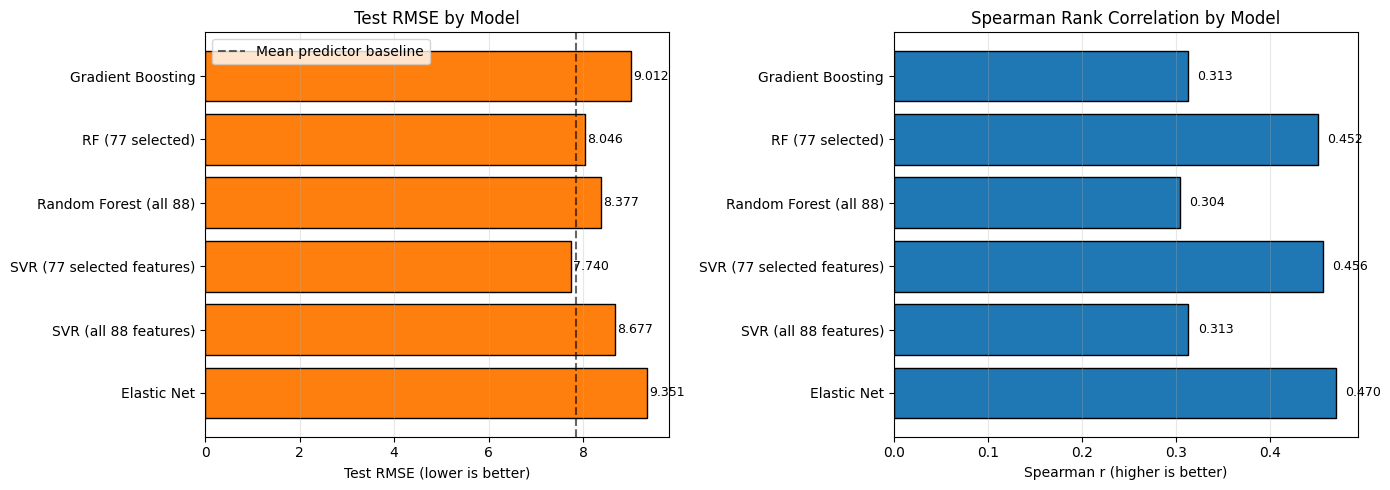

In [25]:
# Summary bar chart
import matplotlib.pyplot as plt

names = list(all_models.keys())
rmses = [np.sqrt(mean_squared_error(y_test, p)) for p in all_models.values()]
spearman_rs = [spearmanr(y_test, p)[0] for p in all_models.values()]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# RMSE comparison
bars = ax1.barh(names, rmses, color="tab:orange", edgecolor="black")
ax1.axvline(7.846, color="black", linestyle="--", alpha=0.6, label="Mean predictor baseline")
ax1.set_xlabel("Test RMSE (lower is better)")
ax1.set_title("Test RMSE by Model")
ax1.legend()
ax1.grid(alpha=0.3, axis="x")
for bar, val in zip(bars, rmses):
    ax1.text(val + 0.05, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

# Spearman correlation
bars2 = ax2.barh(names, spearman_rs, color="tab:blue", edgecolor="black")
ax2.set_xlabel("Spearman r (higher is better)")
ax2.set_title("Spearman Rank Correlation by Model")
ax2.grid(alpha=0.3, axis="x")
for bar, val in zip(bars2, spearman_rs):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

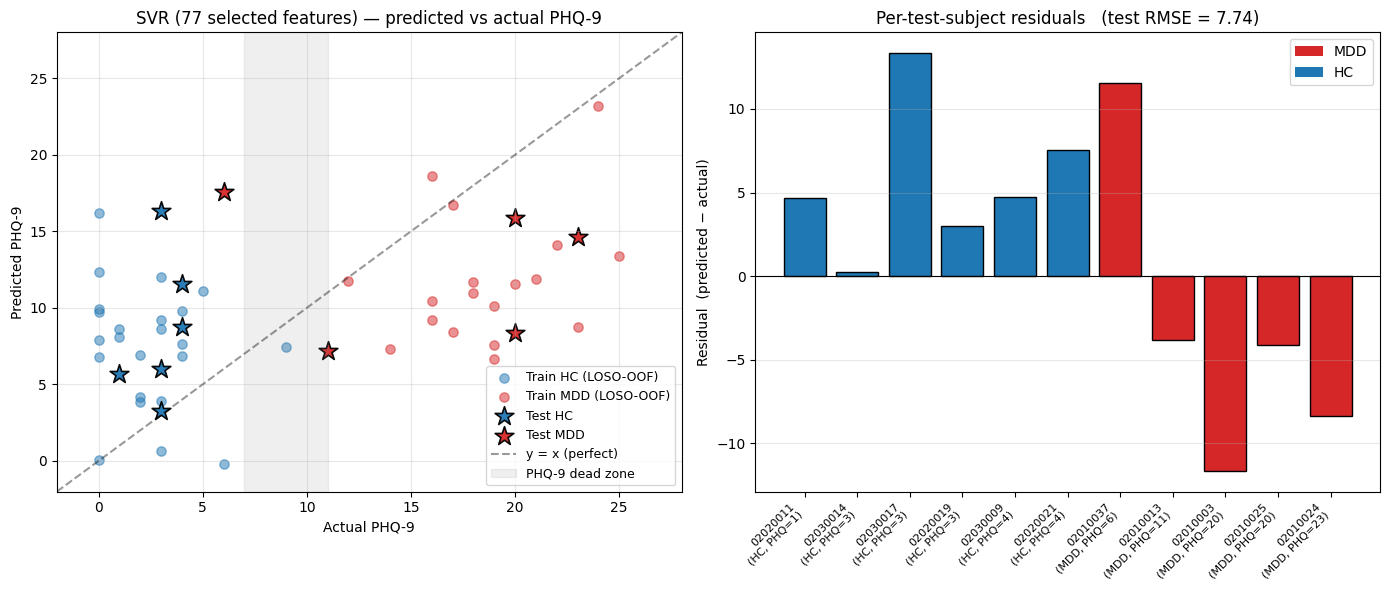

In [ ]:
## SVR (77 Selected Features) — Predicted vs Actual PHQ-9
#
# Visualization of the best SVR model's predictions against actual PHQ-9 scores.
# Left panel shows predicted vs actual PHQ-9 for both training (LOSO out-of-fold)
# and test subjects, colored by MDD/HC group. The dashed line represents perfect
# prediction and the gray band marks the PHQ-9 dead zone (7-11) where very few
# subjects fall. Right panel shows per-test-subject residuals (predicted minus actual)
# sorted by actual PHQ-9 score, which helps identify where the model over- or
# under-predicts.

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.svm import SVR

# Get LOSO out-of-fold predictions on training set for diagnostic plotting
best_svr = svr_sel.best_estimator_
loso_pred_train_svr = cross_val_predict(
    SVR(kernel="rbf", C=best_svr.C, epsilon=best_svr.epsilon, gamma=best_svr.gamma),
    X_tr_sel, y_train, cv=LeaveOneOut()
)

# Test predictions
y_pred_svr_test = best_svr.predict(X_te_sel)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: predicted vs actual
ax = axes[0]
train_is_mdd = (grp_train == "MDD")
test_is_mdd = (grp_test == "MDD")

ax.scatter(y_train[~train_is_mdd], loso_pred_train_svr[~train_is_mdd],
           s=45, alpha=0.5, c="tab:blue", marker="o", label="Train HC (LOSO-OOF)")
ax.scatter(y_train[train_is_mdd], loso_pred_train_svr[train_is_mdd],
           s=45, alpha=0.5, c="tab:red", marker="o", label="Train MDD (LOSO-OOF)")
ax.scatter(y_test[~test_is_mdd], y_pred_svr_test[~test_is_mdd],
           s=200, alpha=0.95, c="tab:blue", marker="*",
           edgecolors="black", linewidths=1.2, label="Test HC")
ax.scatter(y_test[test_is_mdd], y_pred_svr_test[test_is_mdd],
           s=200, alpha=0.95, c="tab:red", marker="*",
           edgecolors="black", linewidths=1.2, label="Test MDD")

lims = [-2, 28]
ax.plot(lims, lims, "k--", alpha=0.4, label="y = x (perfect)")
ax.axvspan(7, 11, color="gray", alpha=0.12, label="PHQ-9 dead zone")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Actual PHQ-9")
ax.set_ylabel("Predicted PHQ-9")
ax.set_title("SVR (77 selected features) — predicted vs actual PHQ-9")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)

# --- Panel 2: per-test-subject residuals
ax = axes[1]
test_results_svr = {
    "subject_id": idx_test,
    "group": grp_test,
    "PHQ9_actual": y_test,
    "PHQ9_pred": y_pred_svr_test,
    "abs_error": np.abs(y_test - y_pred_svr_test),
}
import pandas as pd
residuals_df = pd.DataFrame(test_results_svr).set_index("subject_id").sort_values("PHQ9_actual")
colors = ["tab:red" if g == "MDD" else "tab:blue" for g in residuals_df["group"]]
resid = residuals_df["PHQ9_pred"] - residuals_df["PHQ9_actual"]

ax.bar(range(len(residuals_df)), resid, color=colors, edgecolor="black")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(range(len(residuals_df)))
ax.set_xticklabels(
    [f"{sid}\n({g}, PHQ={p})" for sid, g, p in
     zip(residuals_df.index, residuals_df["group"], residuals_df["PHQ9_actual"])],
    rotation=45, ha="right", fontsize=8,
)
ax.set_ylabel("Residual  (predicted − actual)")
rmse_svr = float(np.sqrt(((y_test - y_pred_svr_test) ** 2).mean()))
ax.set_title(f"Per-test-subject residuals   (test RMSE = {rmse_svr:.2f})")
ax.grid(alpha=0.3, axis="y")
ax.legend(handles=[Patch(facecolor="tab:red", label="MDD"),
                   Patch(facecolor="tab:blue", label="HC")],
          loc="best")

plt.tight_layout()
plt.show()

Top 20 most important features:
                                   feature  importance_mean  importance_std
                     HNRdBACF_sma3nz_amean         7.950896        4.162692
               shimmerLocaldB_sma3nz_amean         2.617732        2.493836
               StddevUnvoicedSegmentLength         2.012656        5.299411
               logRelF0-H1-A3_sma3nz_amean         1.333124        3.502163
              slopeUV500-1500_sma3nz_amean         1.329439        2.184967
                          mfcc4_sma3_amean         1.257083        1.066068
                       mfcc4V_sma3nz_amean         1.243919        2.398364
F0semitoneFrom27.5Hz_sma3nz_percentile50.0         1.076095        1.151648
    F0semitoneFrom27.5Hz_sma3nz_stddevNorm         1.049050        2.221060
F0semitoneFrom27.5Hz_sma3nz_percentile20.0         0.820938        1.095906
         F0semitoneFrom27.5Hz_sma3nz_amean         0.810590        1.075208
                  mfcc3V_sma3nz_stddevNorm         0.748

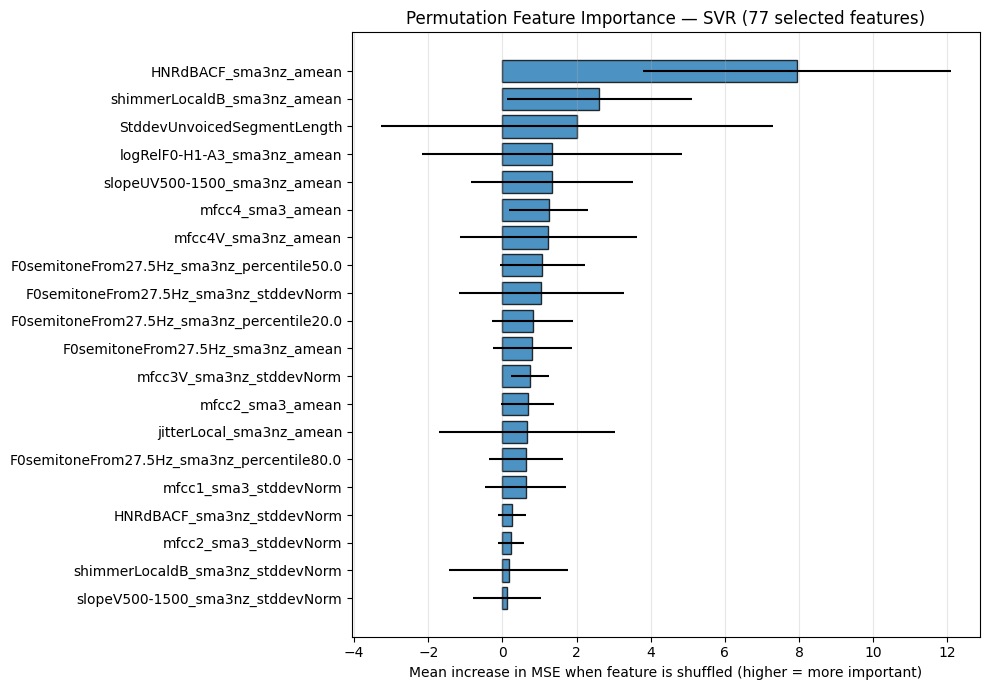

In [28]:
## Feature Importance Analysis — SVR (77 Selected Features)
#
# Since SVR does not have built-in feature importance like tree-based models,
# we use permutation importance — randomly shuffling one feature at a time and
# measuring how much the RMSE increases. A larger increase means the model
# relies more on that feature. We run this on the test set using the best SVR
# model trained on the 77 Elastic Net-selected features.

from sklearn.inspection import permutation_importance

# Run permutation importance on the test set
perm = permutation_importance(
    best_svr, X_te_sel, y_test,
    n_repeats=30,
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1,
)

feature_names = list(subject_mean_88.columns)
# Map back to original feature names
feature_names_sel = [feature_names[i] for i in range(len(feature_names)) if nonzero_mask[i]]

# Build a sorted DataFrame
import pandas as pd
importance_df = pd.DataFrame({
    "feature": feature_names_sel,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

print("Top 20 most important features:")
print(importance_df.head(20).to_string(index=False))

# Plot top 20
fig, ax = plt.subplots(figsize=(10, 7))
top20 = importance_df.head(20)
ax.barh(top20["feature"][::-1], top20["importance_mean"][::-1],
        xerr=top20["importance_std"][::-1],
        color="tab:blue", edgecolor="black", alpha=0.8)
ax.set_xlabel("Mean increase in MSE when feature is shuffled (higher = more important)")
ax.set_title("Permutation Feature Importance — SVR (77 selected features)")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

In [34]:
## SVR by Valence and Task

# We repeat the valence and task subset analysis from the Elastic Net (Cells 10-12)
# using our best SVR configuration (77 Elastic Net-selected features, tuned RBF kernel).
# For each subset, we compute the per-subject mean over only those files, apply the
# same 80/20 split, and run LOSO grid search. This lets us compare SVR and Elastic Net
# directly on which emotional context and speech task is most predictive of PHQ-9.

# Redefine valence and task file groups from audio_file_map
VALENCES = ["positive", "neutral", "negative"]
TASKS = audio_file_map["task"].unique().tolist()

valence_file_groups = {
    v: audio_file_map.loc[audio_file_map["valence"] == v, "file_number"].tolist()
    for v in VALENCES
}

task_file_groups = {
    t: audio_file_map.loc[audio_file_map["task"] == t, "file_number"].tolist()
    for t in TASKS
}

print("Valence → file numbers:")
for v, files in valence_file_groups.items():
    print(f"  {v:9s} ({len(files)} files): {files}")

print("\nTask → file numbers:")
for t, files in task_file_groups.items():
    print(f"  {t:22s} ({len(files):2d} files): {files}")

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, GridSearchCV, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import spearmanr
import numpy as np
import pandas as pd

def fit_subset_svr(file_numbers, label):
    """Per-subject mean over file_numbers, LOSO SVR on the same
    80/20 split. Uses only the 77 Elastic Net-selected features."""

    frames = [func_dfs[fn] for fn in file_numbers if fn in func_dfs]
    stacked_sub = pd.concat(frames, axis=0)
    subj_mean = stacked_sub.groupby(level=0).mean()
    subj_mean = subj_mean.loc[subject_info.index]

    # Apply the same nonzero_mask to select the 77 features
    X_tr = subj_mean.loc[idx_train].values[:, nonzero_mask]
    X_te = subj_mean.loc[idx_test].values[:, nonzero_mask]

    scaler = StandardScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    X_te_s = scaler.transform(X_te)

    loo = LeaveOneOut()
    svr_cv = GridSearchCV(
        SVR(kernel="rbf"),
        {"C": [0.1, 1, 10, 100], "epsilon": [0.1, 0.5, 1.0, 2.0], "gamma": ["scale", "auto"]},
        cv=loo, scoring="neg_mean_squared_error", n_jobs=-1,
    ).fit(X_tr_s, y_train)

    best = svr_cv.best_estimator_
    loso_train = cross_val_predict(
        SVR(kernel="rbf", C=best.C, epsilon=best.epsilon, gamma=best.gamma),
        X_tr_s, y_train, cv=loo
    )
    y_pred_te = best.predict(X_te_s)
    rho, pval = spearmanr(y_test, y_pred_te)

    return {
        "label": label,
        "n_files": len(file_numbers),
        "C": best.C,
        "epsilon": best.epsilon,
        "gamma": best.gamma,
        "train_loso_pred": loso_train,
        "test_pred": y_pred_te,
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_pred_te))),
        "test_mae": float(mean_absolute_error(y_test, y_pred_te)),
        "test_r2": float(r2_score(y_test, y_pred_te)),
        "spearman_r": float(rho),
        "spearman_p": float(pval),
        "train_loso_rmse": float(np.sqrt(mean_squared_error(y_train, loso_train))),
    }

# --- Run by valence ---
print("Running SVR by valence...")
svr_valence_results = {
    v: fit_subset_svr(files, f"valence={v}")
    for v, files in valence_file_groups.items()
}

valence_svr_summary = pd.DataFrame({
    v: {
        "n_files": r["n_files"],
        "train_LOSO_RMSE": round(r["train_loso_rmse"], 3),
        "test_RMSE": round(r["test_rmse"], 3),
        "test_MAE": round(r["test_mae"], 3),
        "test_R2": round(r["test_r2"], 3),
        "Spearman_r": round(r["spearman_r"], 3),
        "Spearman_p": round(r["spearman_p"], 3),
    } for v, r in svr_valence_results.items()
}).T
print("\nSVR Valence Summary:")
print(valence_svr_summary)

# --- Run by task ---
print("\nRunning SVR by task...")
svr_task_results = {
    t: fit_subset_svr(files, f"task={t}")
    for t, files in task_file_groups.items()
}

task_svr_summary = pd.DataFrame({
    t: {
        "n_files": r["n_files"],
        "train_LOSO_RMSE": round(r["train_loso_rmse"], 3),
        "test_RMSE": round(r["test_rmse"], 3),
        "test_MAE": round(r["test_mae"], 3),
        "test_R2": round(r["test_r2"], 3),
        "Spearman_r": round(r["spearman_r"], 3),
        "Spearman_p": round(r["spearman_p"], 3),
    } for t, r in svr_task_results.items()
}).T

print("\nSVR Task Summary (full):")
print(task_svr_summary.to_string())
print(f"\nMean-predictor baseline test RMSE: {np.sqrt(mean_squared_error(y_test, baseline_pred)):.3f}")

Valence → file numbers:
  positive  (9 files): [1, 2, 3, 4, 5, 6, 20, 21, 26]
  neutral   (9 files): [7, 8, 9, 10, 11, 12, 22, 23, 27]
  negative  (9 files): [13, 14, 15, 16, 17, 18, 24, 25, 28]

Task → file numbers:
  Interview              (18 files): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
  Passage Reading        ( 1 files): [19]
  Word Reading           ( 6 files): [20, 21, 22, 23, 24, 25]
  Picture Description    ( 4 files): [26, 27, 28, 29]
Running SVR by valence...

SVR Valence Summary:
          n_files  train_LOSO_RMSE  test_RMSE  test_MAE  test_R2  Spearman_r  \
positive      9.0            7.315      8.842     7.666   -0.278       0.235   
neutral       9.0            8.129      7.314     6.215    0.126       0.470   
negative      9.0            7.319      7.805     6.687    0.004       0.438   

          Spearman_p  
positive       0.487  
neutral        0.145  
negative       0.178  

Running SVR by task...

SVR Task Summary (full):
             

In [33]:
print(task_svr_summary.to_string())

                     n_files  train_LOSO_RMSE  test_RMSE  test_MAE  test_R2  Spearman_r  Spearman_p
Interview               18.0            7.993      7.069     6.230    0.183       0.576       0.064
Passage Reading          1.0            8.019      7.175     6.143    0.159       0.479       0.136
Word Reading             6.0            7.860      8.111     7.047   -0.075       0.277       0.410
Picture Description      4.0            7.461      7.271     6.669    0.136       0.465       0.149


In [36]:
# Rerun Elastic Net valence and task subset analysis
from sklearn.linear_model import ElasticNetCV, ElasticNet
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.preprocessing import StandardScaler

def fit_subset_loso_enet(file_numbers, label):
    frames = [func_dfs[fn] for fn in file_numbers if fn in func_dfs]
    stacked_sub = pd.concat(frames, axis=0)
    subj_mean = stacked_sub.groupby(level=0).mean()
    subj_mean = subj_mean.loc[subject_info.index]

    X_tr = subj_mean.loc[idx_train].values
    X_te = subj_mean.loc[idx_test].values

    scaler = StandardScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    X_te_s = scaler.transform(X_te)

    loo = LeaveOneOut()
    enet = ElasticNetCV(
        l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99, 1.0],
        alphas=np.logspace(-3, 1, 40),
        cv=loo, max_iter=20000, n_jobs=-1, random_state=42,
    ).fit(X_tr_s, y_train)

    final = ElasticNet(alpha=enet.alpha_, l1_ratio=enet.l1_ratio_,
                       max_iter=20000, random_state=42)
    loso_train = cross_val_predict(final, X_tr_s, y_train, cv=loo)
    y_pred_te = enet.predict(X_te_s)

    return {
        "label": label,
        "n_files": len(file_numbers),
        "test_pred": y_pred_te,
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_pred_te))),
        "test_mae": float(mean_absolute_error(y_test, y_pred_te)),
        "test_r2": float(r2_score(y_test, y_pred_te)),
        "train_loso_pred": loso_train,
        "train_loso_rmse": float(np.sqrt(mean_squared_error(y_train, loso_train))),
    }

print("Running Elastic Net by valence and task...")
valence_results = {
    v: fit_subset_loso_enet(files, f"valence={v}")
    for v, files in valence_file_groups.items()
}
task_results = {
    t: fit_subset_loso_enet(files, f"task={t}")
    for t, files in task_file_groups.items()
}
print("Done.")

Running Elastic Net by valence and task...


/Users/alicia/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.179e-01, tolerance: 2.948e-01
  model = cd_fast.enet_coordinate_descent(
/Users/alicia/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.337e-01, tolerance: 2.961e-01
  model = cd_fast.enet_coordinate_descent(
/Users/alicia/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing reg

Done.


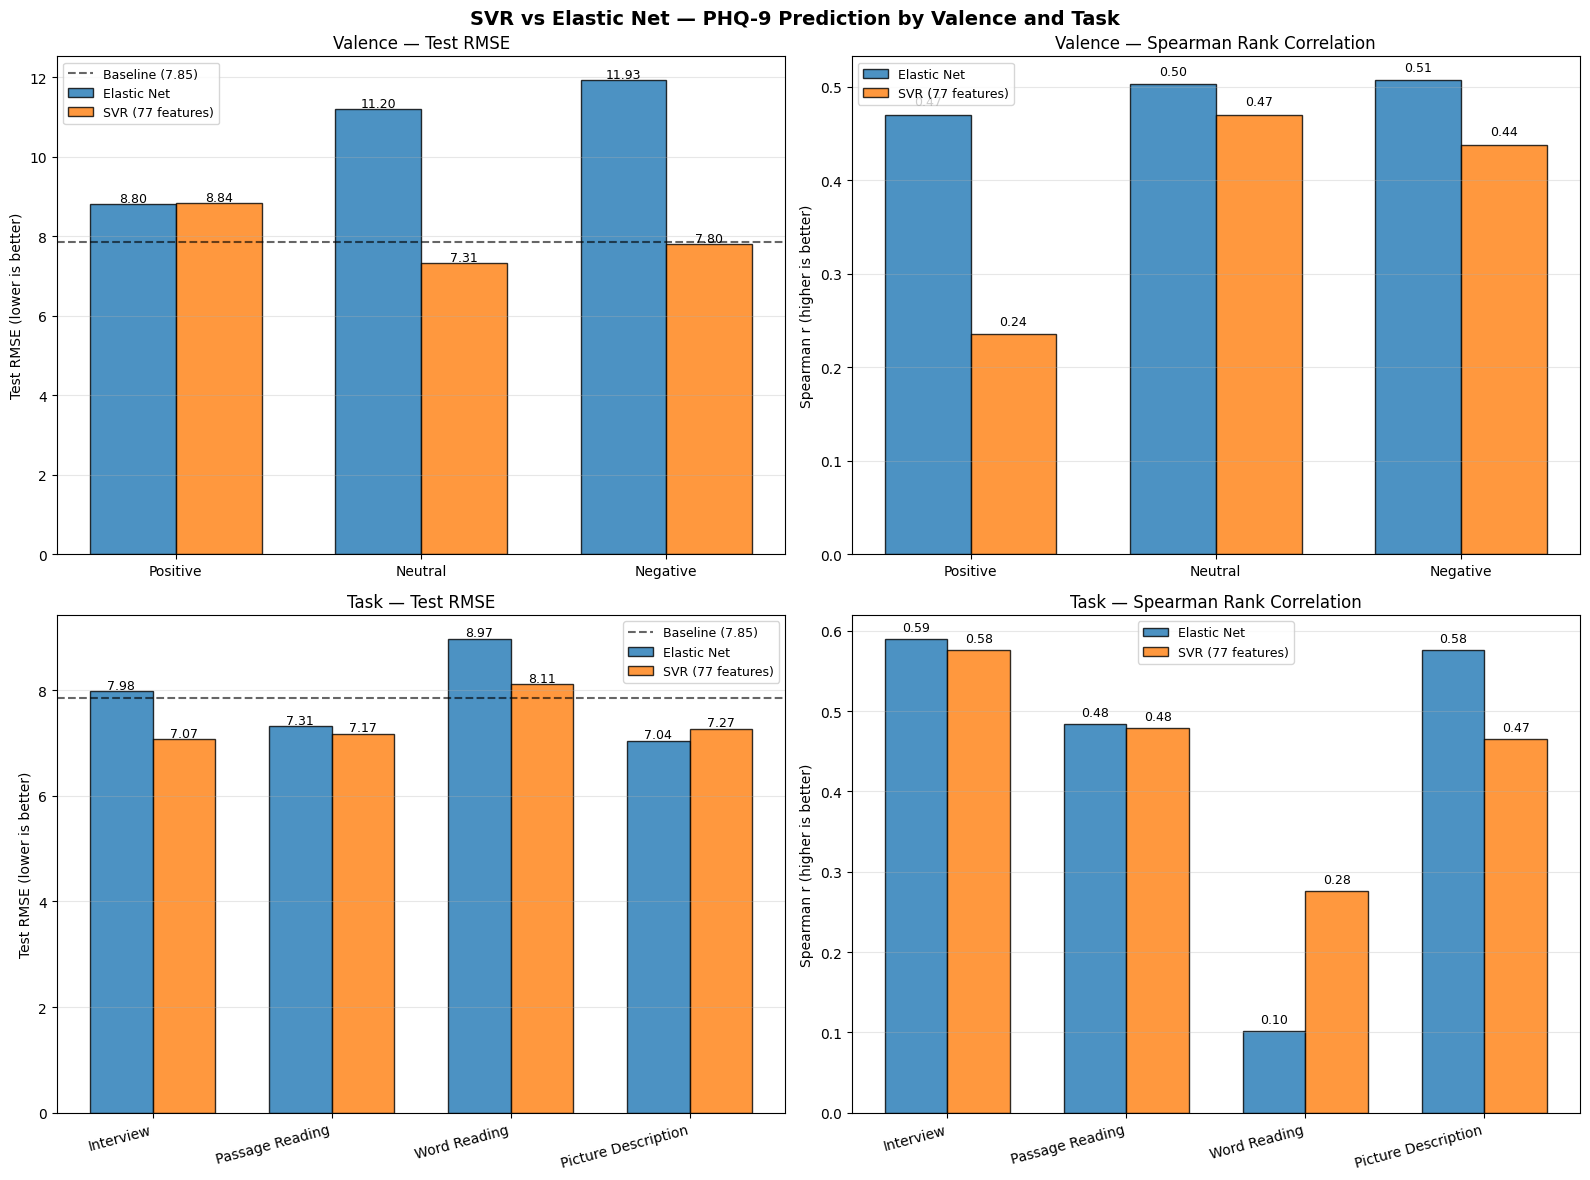

In [37]:
## SVR vs Elastic Net — Valence and Task Comparison
#
# Side-by-side bar charts comparing test RMSE and Spearman rank correlation
# between SVR (77 selected features) and Elastic Net across valence groups
# and task types. The dashed line marks the mean-predictor baseline (7.846).
# This lets us see whether SVR and Elastic Net agree on which speech contexts
# are most predictive of PHQ-9.

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

baseline_rmse = float(np.sqrt(((y_test - y_train.mean()) ** 2).mean()))
w = 0.35

# ── Valence RMSE ──────────────────────────────────────────────
ax = axes[0, 0]
xpos = np.arange(len(VALENCES))
enet_val_rmse = [valence_results[v]["test_rmse"] for v in VALENCES]
svr_val_rmse  = [svr_valence_results[v]["test_rmse"] for v in VALENCES]

b1 = ax.bar(xpos - w/2, enet_val_rmse, w, label="Elastic Net",
            color="tab:blue", edgecolor="black", alpha=0.8)
b2 = ax.bar(xpos + w/2, svr_val_rmse, w, label="SVR (77 features)",
            color="tab:orange", edgecolor="black", alpha=0.8)
ax.axhline(baseline_rmse, color="black", linestyle="--", alpha=0.6,
           label=f"Baseline ({baseline_rmse:.2f})")
for bar, val in zip(b1, enet_val_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}",
            ha="center", fontsize=9)
for bar, val in zip(b2, svr_val_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}",
            ha="center", fontsize=9)
ax.set_xticks(xpos)
ax.set_xticklabels([v.capitalize() for v in VALENCES])
ax.set_ylabel("Test RMSE (lower is better)")
ax.set_title("Valence — Test RMSE")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")

# ── Valence Spearman ──────────────────────────────────────────
ax = axes[0, 1]
enet_val_rho = [valence_results[v]["test_r2"] for v in VALENCES]
svr_val_rho  = [svr_valence_results[v]["spearman_r"] for v in VALENCES]
enet_val_spear = [spearmanr(y_test, valence_results[v]["test_pred"])[0] for v in VALENCES]

b1 = ax.bar(xpos - w/2, enet_val_spear, w, label="Elastic Net",
            color="tab:blue", edgecolor="black", alpha=0.8)
b2 = ax.bar(xpos + w/2, svr_val_rho, w, label="SVR (77 features)",
            color="tab:orange", edgecolor="black", alpha=0.8)
for bar, val in zip(b1, enet_val_spear):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}",
            ha="center", fontsize=9)
for bar, val in zip(b2, svr_val_rho):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}",
            ha="center", fontsize=9)
ax.set_xticks(xpos)
ax.set_xticklabels([v.capitalize() for v in VALENCES])
ax.set_ylabel("Spearman r (higher is better)")
ax.set_title("Valence — Spearman Rank Correlation")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")

# ── Task RMSE ─────────────────────────────────────────────────
ax = axes[1, 0]
xpos_t = np.arange(len(TASKS))
enet_task_rmse = [task_results[t]["test_rmse"] for t in TASKS]
svr_task_rmse  = [svr_task_results[t]["test_rmse"] for t in TASKS]

b1 = ax.bar(xpos_t - w/2, enet_task_rmse, w, label="Elastic Net",
            color="tab:blue", edgecolor="black", alpha=0.8)
b2 = ax.bar(xpos_t + w/2, svr_task_rmse, w, label="SVR (77 features)",
            color="tab:orange", edgecolor="black", alpha=0.8)
ax.axhline(baseline_rmse, color="black", linestyle="--", alpha=0.6,
           label=f"Baseline ({baseline_rmse:.2f})")
for bar, val in zip(b1, enet_task_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}",
            ha="center", fontsize=9)
for bar, val in zip(b2, svr_task_rmse):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.05, f"{val:.2f}",
            ha="center", fontsize=9)
ax.set_xticks(xpos_t)
ax.set_xticklabels(TASKS, rotation=15, ha="right")
ax.set_ylabel("Test RMSE (lower is better)")
ax.set_title("Task — Test RMSE")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")

# ── Task Spearman ─────────────────────────────────────────────
ax = axes[1, 1]
enet_task_spear = [spearmanr(y_test, task_results[t]["test_pred"])[0] for t in TASKS]
svr_task_spear  = [svr_task_results[t]["spearman_r"] for t in TASKS]

b1 = ax.bar(xpos_t - w/2, enet_task_spear, w, label="Elastic Net",
            color="tab:blue", edgecolor="black", alpha=0.8)
b2 = ax.bar(xpos_t + w/2, svr_task_spear, w, label="SVR (77 features)",
            color="tab:orange", edgecolor="black", alpha=0.8)
for bar, val in zip(b1, enet_task_spear):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}",
            ha="center", fontsize=9)
for bar, val in zip(b2, svr_task_spear):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}",
            ha="center", fontsize=9)
ax.set_xticks(xpos_t)
ax.set_xticklabels(TASKS, rotation=15, ha="right")
ax.set_ylabel("Spearman r (higher is better)")
ax.set_title("Task — Spearman Rank Correlation")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, axis="y")

fig.suptitle("SVR vs Elastic Net — PHQ-9 Prediction by Valence and Task",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Per-subject error comparison (sorted by actual PHQ-9):
           group  PHQ9_actual  enet_pred  svr_pred  enet_abs_error  svr_abs_error better_model
subject_id                                                                                    
02020011      HC            1       8.10      5.65            7.10           4.65          SVR
02030014      HC            3       6.50      3.26            3.50           0.26          SVR
02030017      HC            3      13.38     16.33           10.38          13.33  Elastic Net
02020019      HC            3       6.61      6.03            3.61           3.03          SVR
02030009      HC            4       7.99      8.75            3.99           4.75  Elastic Net
02020021      HC            4       9.27     11.54            5.27           7.54  Elastic Net
02010037     MDD            6      26.95     17.56           20.95          11.56          SVR
02010013     MDD           11       1.76      7.18            9.24           3.82         

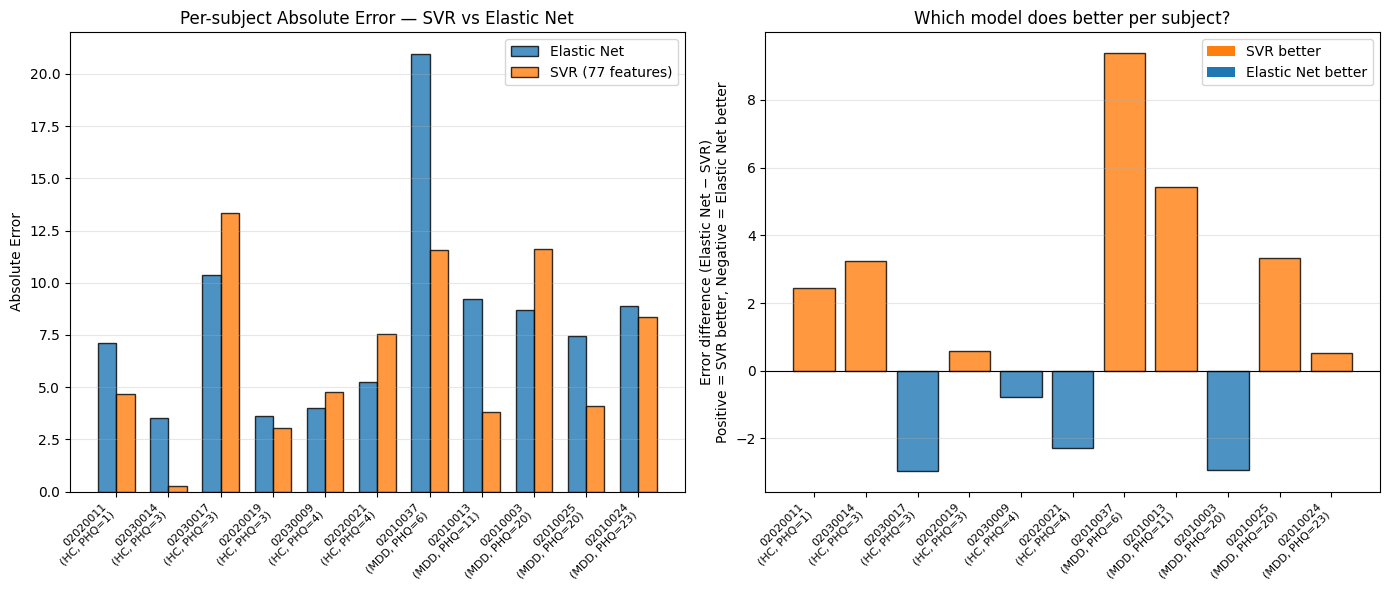

In [38]:
## Error Analysis — SVR vs Elastic Net
#
# We compare per-subject prediction errors between SVR (77 selected features)
# and Elastic Net on the test set. Subjects that both models get wrong are
# likely dataset outliers or genuinely hard cases, while subjects where one
# model does better than the other reveal where each model's strengths lie.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Get predictions from both models
y_pred_enet_test = enet_cv.predict(X_test_s)
y_pred_svr_test = best_svr.predict(X_te_sel)

# Build comparison dataframe
error_df = pd.DataFrame({
    "subject_id": idx_test,
    "group": grp_test,
    "PHQ9_actual": y_test,
    "enet_pred": y_pred_enet_test,
    "svr_pred": y_pred_svr_test,
    "enet_abs_error": np.abs(y_test - y_pred_enet_test),
    "svr_abs_error": np.abs(y_test - y_pred_svr_test),
}).set_index("subject_id")

error_df["better_model"] = np.where(
    error_df["enet_abs_error"] < error_df["svr_abs_error"], "Elastic Net",
    np.where(error_df["svr_abs_error"] < error_df["enet_abs_error"], "SVR", "Tie")
)
error_df["error_diff"] = error_df["enet_abs_error"] - error_df["svr_abs_error"]

print("Per-subject error comparison (sorted by actual PHQ-9):")
print(error_df[["group", "PHQ9_actual", "enet_pred", "svr_pred",
                "enet_abs_error", "svr_abs_error", "better_model"]].round(2).sort_values("PHQ9_actual").to_string())

print(f"\nSubjects where SVR wins:        {(error_df['better_model'] == 'SVR').sum()}")
print(f"Subjects where Elastic Net wins: {(error_df['better_model'] == 'Elastic Net').sum()}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: side by side abs error per subject
ax = axes[0]
subjects = error_df.sort_values("PHQ9_actual").index
x = np.arange(len(subjects))
ax.bar(x - w/2, error_df.loc[subjects, "enet_abs_error"], w,
       label="Elastic Net", color="tab:blue", edgecolor="black", alpha=0.8)
ax.bar(x + w/2, error_df.loc[subjects, "svr_abs_error"], w,
       label="SVR (77 features)", color="tab:orange", edgecolor="black", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{sid}\n({g}, PHQ={p})" for sid, g, p in
     zip(subjects, error_df.loc[subjects, "group"],
         error_df.loc[subjects, "PHQ9_actual"])],
    rotation=45, ha="right", fontsize=8
)
ax.set_ylabel("Absolute Error")
ax.set_title("Per-subject Absolute Error — SVR vs Elastic Net")
ax.legend()
ax.grid(alpha=0.3, axis="y")

# Panel 2: error difference (positive = SVR better, negative = Elastic Net better)
ax = axes[1]
diffs = error_df.loc[subjects, "error_diff"]
colors = ["tab:blue" if d < 0 else "tab:orange" for d in diffs]
ax.bar(x, diffs, color=colors, edgecolor="black", alpha=0.8)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{sid}\n({g}, PHQ={p})" for sid, g, p in
     zip(subjects, error_df.loc[subjects, "group"],
         error_df.loc[subjects, "PHQ9_actual"])],
    rotation=45, ha="right", fontsize=8
)
ax.set_ylabel("Error difference (Elastic Net − SVR)\nPositive = SVR better, Negative = Elastic Net better")
ax.set_title("Which model does better per subject?")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="tab:orange", label="SVR better"),
                   Patch(facecolor="tab:blue", label="Elastic Net better")])
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()